In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Cấu hình hiển thị tiếng Việt cho Matplotlib
plt.rcParams['font.family'] = 'Arial' 
sns.set_theme(style="whitegrid")

# Load Golden Dataset
df = pd.read_parquet("../data/final/golden_board.parquet")
print(f"Loaded {len(df)} records for {df['ticker'].nunique()} companies.")

Loaded 1433 records for 90 companies.


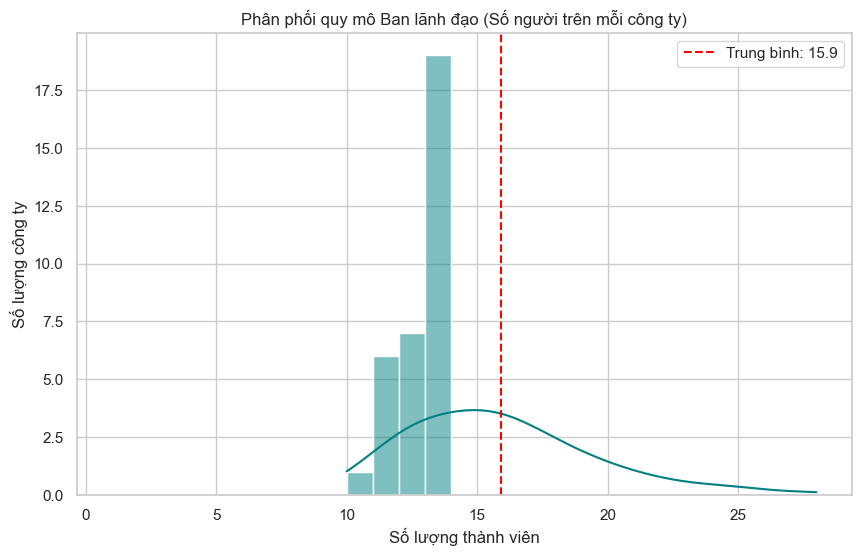

Quy mô trung bình: 15.92
Quy mô lớn nhất: 28 (Ticker: BAB)


In [5]:
plt.figure(figsize=(10, 6))
sns.histplot(board_size['board_size'], bins=range(1, 15), kde=True, color='teal')
plt.title('Phân phối quy mô Ban lãnh đạo (Số người trên mỗi công ty)')
plt.xlabel('Số lượng thành viên')
plt.ylabel('Số lượng công ty')
plt.axvline(board_size['board_size'].mean(), color='red', linestyle='--', label=f"Trung bình: {board_size['board_size'].mean():.1f}")
plt.legend()
plt.show()

print(f"Quy mô trung bình: {board_size['board_size'].mean():.2f}")
print(f"Quy mô lớn nhất: {board_size['board_size'].max()} (Ticker: {board_size.loc[board_size['board_size'].idxmax(), 'ticker']})")

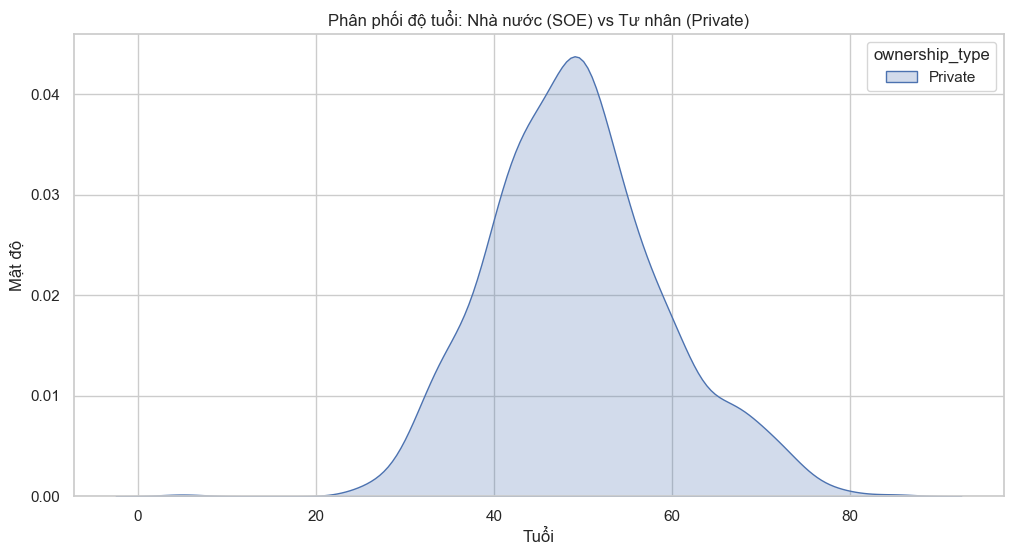

Độ tuổi trung bình theo loại hình sở hữu:
ownership_type
Private    49.337566
Name: age, dtype: float64


In [6]:
plt.figure(figsize=(12, 6))
sns.kdeplot(data=df, x="age", hue="ownership_type", fill=True, common_norm=False)
plt.title('Phân phối độ tuổi: Nhà nước (SOE) vs Tư nhân (Private)')
plt.xlabel('Tuổi')
plt.ylabel('Mật độ')
plt.show()

print("Độ tuổi trung bình theo loại hình sở hữu:")
print(df.groupby('ownership_type')['age'].mean())

C:\Users\Admin\AppData\Local\Temp\ipykernel_51796\1536650602.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_roles.index, x=top_roles.values, palette='viridis')


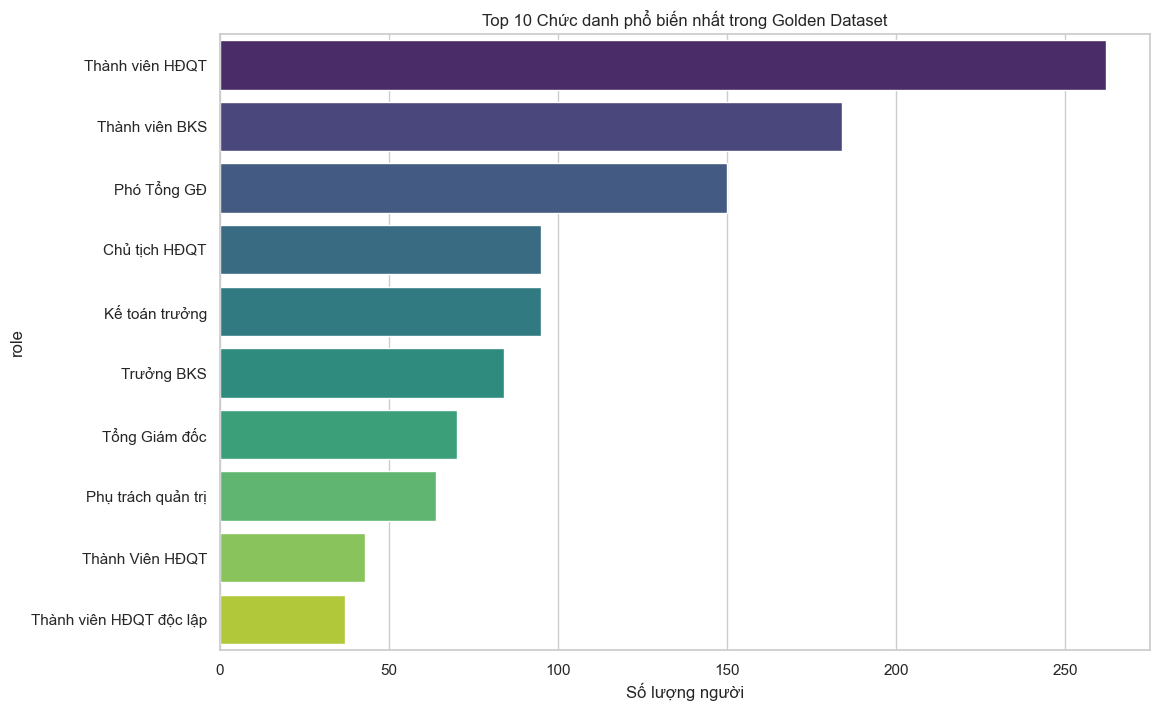

In [7]:
# Lọc ra top 10 chức danh phổ biến nhất
top_roles = df['role'].value_counts().head(10)

plt.figure(figsize=(12, 8))
sns.barplot(y=top_roles.index, x=top_roles.values, palette='viridis')
plt.title('Top 10 Chức danh phổ biến nhất trong Golden Dataset')
plt.xlabel('Số lượng người')
plt.show()

In [8]:
# Xem các cá nhân nắm giữ nhiều cổ phiếu nhất
top_holders = df.sort_values(by='total_shares', ascending=False).head(10)

fig = px.bar(top_holders, x='total_shares', y='person_name', color='ticker',
             title='Top 10 cá nhân trong Ban lãnh đạo nắm giữ nhiều cổ phiếu nhất',
             labels={'total_shares': 'Số lượng cổ phiếu', 'person_name': 'Họ tên'},
             orientation='h')
fig.update_layout(yaxis={'categoryorder':'total ascending'})
fig.show()

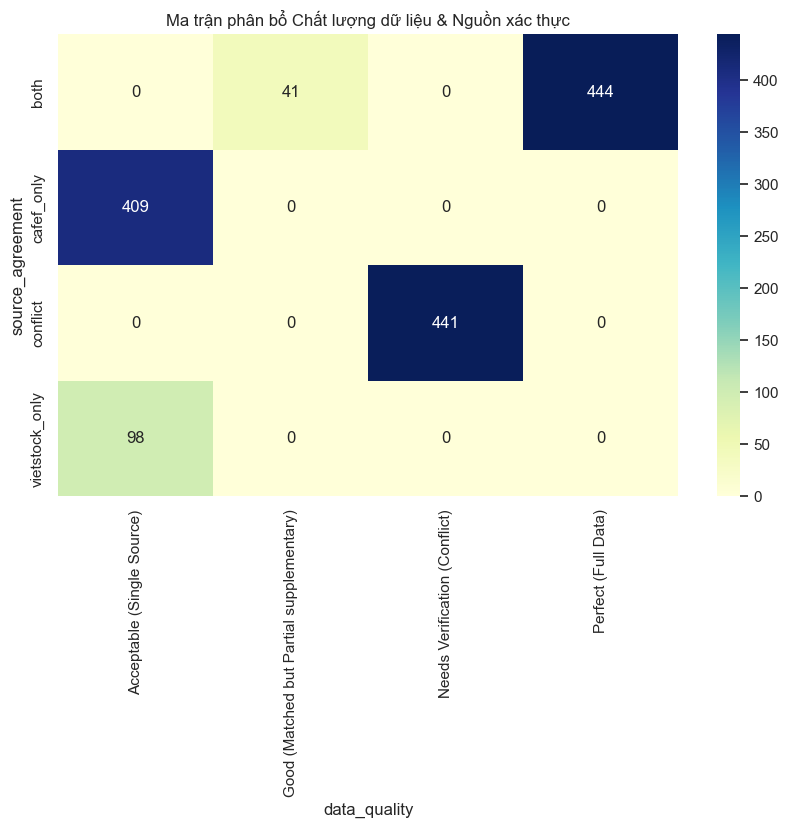

In [9]:
# Xem sự tương quan giữa điểm tin cậy và sự đồng thuận của nguồn
plt.figure(figsize=(10, 6))
quality_pivot = df.pivot_table(index='source_agreement', columns='data_quality', values='ticker', aggfunc='count').fillna(0)
sns.heatmap(quality_pivot, annot=True, fmt='g', cmap='YlGnBu')
plt.title('Ma trận phân bổ Chất lượng dữ liệu & Nguồn xác thực')
plt.show()